<a href="https://colab.research.google.com/github/Shraddha-Bankar/Road_Lane_Detection_System/blob/main/Road_Lane_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing some useful packages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
%matplotlib inline

This image is: <class 'numpy.ndarray'> with dimensions: (540, 960, 3)


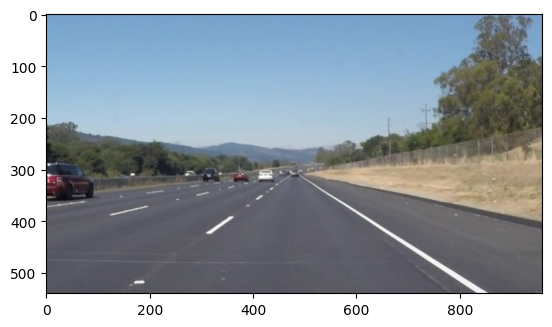

In [ ]:
#reading in an image
image = mpimg.imread('/content/solidWhiteRight.jpg')

#printing out some stats and plotting
print('This image is:', type(image), 'with dimensions:', image.shape)
plt.imshow(image)  # if you wanted to show a single color channel image called 'gray', for example, call as plt.imshow(gray, cmap='gray')

In [ ]:
import math

def grayscale(img):
    """Applies the Grayscale transform
    This will return an image with only one color channel
    but NOTE: to see the returned image as grayscale
    (assuming your grayscaled image is called 'gray')
    you should call plt.imshow(gray, cmap='gray')"""
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Or use BGR2GRAY if you read an image with cv2.imread()
    # return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def canny(img, low_threshold, high_threshold):
    """Applies the Canny transform"""
    return cv2.Canny(img, low_threshold, high_threshold)

def gaussian_blur(img, kernel_size):
    """Applies a Gaussian Noise kernel"""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

def region_of_interest(img, vertices):
    """
    Applies an image mask.

    Only keeps the region of the image defined by the polygon
    formed from `vertices`. The rest of the image is set to black.
    `vertices` should be a numpy array of integer points.
    """
    #defining a blank mask to start with
    mask = np.zeros_like(img)

    #defining a 3 channel or 1 channel color to fill the mask with depending on the input image
    if len(img.shape) > 2:
        channel_count = img.shape[2]  # i.e. 3 or 4 depending on your image
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255

    #filling pixels inside the polygon defined by "vertices" with the fill color
    cv2.fillPoly(mask, vertices, ignore_mask_color)

    #returning the image only where mask pixels are nonzero
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image


def draw_lines(img, lines, color=[255, 0, 0], thickness=10):
    """
    NOTE: this is the function you might want to use as a starting point once you want to
    average/extrapolate the line segments you detect to map out the full
    extent of the lane (going from the result shown in raw-lines-example.mp4
    to that shown in P1_example.mp4).

    Think about things like separating line segments by their
    slope ((y2-y1)/(x2-x1)) to decide which segments are part of the left
    line vs. the right line.  Then, you can average the position of each of
    the lines and extrapolate to the top and bottom of the lane.

    This function draws `lines` with `color` and `thickness`.
    Lines are drawn on the image inplace (mutates the image).
    If you want to make the lines semi-transparent, think about combining
    this function with the weighted_img() function below
    """
    if lines is None:
        return

    imshape = img.shape
    left_lines = []
    right_lines = []
    left_lines_aligned = []
    right_lines_aligned = []

    # Loop over the lines and sort them in left and right lists based on the slope
    for line in lines:
        for x1, y1, x2, y2 in line:
            # Avoid division by zero if x1 == x2
            if (x2 - x1) == 0:
                continue

            m = (y2 - y1) / (x2 - x1)
            b = y1 - (m * x1)
            if m < 0:
                left_lines.append((m, b))
            elif m > 0: # Ensure positive slope for right lines
                right_lines.append((m, b))

    # Initialize ml, bl, mr, br with default values
    ml, bl, mr, br = 0, 0, 0, 0

    # Process left lines
    if len(left_lines) > 0:
        left_m = [line[0] for line in left_lines]
        left_m_avg = np.mean(left_m)
        left_m_std = np.std(left_m)

        # Only keep lines that are close to the average slope
        if left_m_std != 0: # Avoid division by zero if all slopes are the same or left_lines is empty
            for line in left_lines:
                if abs(line[0] - left_m_avg) < left_m_std:
                    left_lines_aligned.append(line)
        else: # If std is 0, it means all slopes are the same or no lines, so all are 'aligned' if present
            left_lines_aligned = left_lines

        if len(left_lines_aligned) > 0:
            ml = np.mean([line[0] for line in left_lines_aligned])
            bl = np.mean([line[1] for line in left_lines_aligned])

    # Process right lines
    if len(right_lines) > 0:
        right_m = [line[0] for line in right_lines]
        right_m_avg = np.mean(right_m)
        right_m_std = np.std(right_m)

        if right_m_std != 0:
            for line in right_lines:
                if abs(line[0] - right_m_avg) < right_m_std:
                    right_lines_aligned.append(line)
        else:
            right_lines_aligned = right_lines

        if len(right_lines_aligned) > 0:
            mr = np.mean([line[0] for line in right_lines_aligned])
            br = np.mean([line[1] for line in right_lines_aligned])

    # Use previous cycle lines coefficients and smoothen lines over time
    smooth_fact = 0.8
    if ml != 0 and abs(ml) < 1000: # Check ml is not zero before using in smoothing
        if previous_lines[0] != 0:
            ml = previous_lines[0] * smooth_fact + ml * (1 - smooth_fact)
            bl = previous_lines[1] * smooth_fact + bl * (1 - smooth_fact)
    elif previous_lines[0] != 0:
        ml = previous_lines[0]
        bl = previous_lines[1]

    if mr != 0 and abs(mr) < 1000: # Check mr is not zero before using in smoothing
        if previous_lines[2] != 0:
            mr = previous_lines[2] * smooth_fact + mr * (1 - smooth_fact)
            br = previous_lines[3] * smooth_fact + br * (1 - smooth_fact)
    elif previous_lines[2] != 0:
        mr = previous_lines[2]
        br = previous_lines[3]

    # Interpolate the resulting average line to intersect the edges of the region of interest
    x1l, y1l, x2l, y2l = 0, imshape[0], 0, int(6 * imshape[0] / 10) # Default values
    if ml != 0: # Ensure ml is not zero to avoid division by zero
        x1l = int((bl - imshape[0]) / (-1 * ml))
        x2l = int((bl - 6 * imshape[0] / 10) / (-1 * ml))

    x1r, y1r, x2r, y2r = 0, int(6 * imshape[0] / 10), 0, imshape[0] # Default values
    if mr != 0: # Ensure mr is not zero to avoid division by zero
        x1r = int((br - 6 * imshape[0] / 10) / (-1 * mr))
        x2r = int((br - imshape[0]) / (-1 * mr))

    # Draw lines only if valid slopes are found for both left and right lines and x2l < x1r
    if ml != 0 and mr != 0 and x2l < x1r:
        cv2.line(img, (x1l, y1l), (x2l, y2l), [0, 255, 0], thickness)
        cv2.line(img, (x1r, y1r), (x2r, y2r), [0, 0, 255], thickness)

    # Store lines coefficients for next cycle
    previous_lines[0] = ml
    previous_lines[1] = bl
    previous_lines[2] = mr
    previous_lines[3] = br


def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """
    `img` should be the output of a Canny transform.

    Returns an image with hough lines drawn.
    """
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    draw_lines(line_img, lines)
    return line_img

# Python 3 has support for cool math symbols.

def weighted_img(img, initial_img, α=0.8, β=0.6, γ=0.):
    """
    `img` is the output of the hough_lines(), An image with lines drawn on it.
    Should be a blank image (all black) with lines drawn on it.

    `initial_img` should be the image before any processing.

    The result image is computed as follows:

    initial_img * α + img * β + γ
    NOTE: initial_img and img must be the same shape!
    """
    return cv2.addWeighted(initial_img, α, img, β, γ)


In [ ]:
import os
os.listdir("/content/")

['.config',
 'solidYellowCurve.jpg',
 '4.JPG',
 'ignore.txt',
 'solidYellowCurve2.jpg',
 'solidWhiteRight.mp4',
 'LaneLines.gif',
 '1.JPG',
 'solidYellowLeft.jpg',
 'lanes_marked_whiteCarLaneSwitch.jpg',
 'lanes_marked_solidWhiteRight.jpg',
 'lanes_marked_solidWhiteCurve.jpg',
 'solidYellowLeft.mp4',
 '7.JPG',
 'lanes_marked_solidYellowCurve2.jpg',
 'grayscale.jpg',
 '5p.JPG',
 '2.JPG',
 'raw-lines-example.mp4',
 '5.JPG',
 'lanes_marked_solidYellowCurve.jpg',
 'solidWhiteCurve.jpg',
 'line-segments-example.jpg',
 '3.JPG',
 'challenge.mp4',
 'solidWhiteRight.jpg',
 'lanes_marked_solidYellowLeft.jpg',
 '6.JPG',
 'whiteCarLaneSwitch.jpg',
 'laneLines_thirdPass.jpg',
 'P1_example.mp4',
 'sample_data']

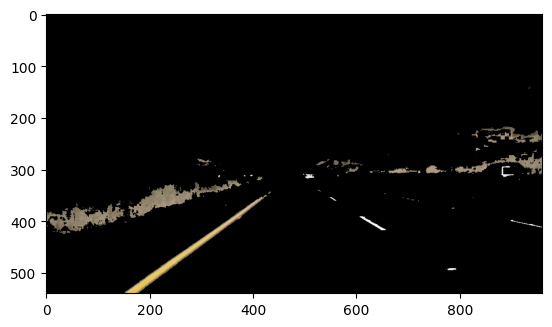

In [ ]:
img = mpimg.imread('/content/solidYellowCurve.jpg')

### color selection###
hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

mask_white = cv2.inRange(img, (200,200,200), (255, 255, 255))
mask_yellow = cv2.inRange(hsv_img, (15,60,20), (25, 255, 255))
color_mask = cv2.bitwise_or(mask_white, mask_yellow)
masked_img = np.copy(img)
masked_img[color_mask == 0] = [0,0,0]

plt.imshow(masked_img)

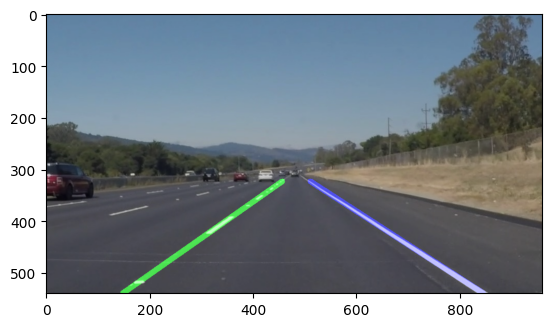

In [ ]:
# TODO: Build your pipeline that will draw lane lines on the test_images
# then save them to the test_images_output directory.
previous_lines = [0, 0, 0, 0]
def lane_finding_pipeline(img):

    ### create a color mask ###
    #convert from RGB to HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    #define two color masks for yellow and white
    #white mask is applied in RGB color space, it's easier to tune the values
    #values from 200 to 255 on all colors are picked from trial and error
    mask_white = cv2.inRange(img, (200,200,200), (255, 255, 255))
    #yellow mask is done in HSV color space since it's easier to identify the hue of a certain color
    #values from 15 to 25 for hue and above 60 for saturation are picked from trial and error
    mask_yellow = cv2.inRange(hsv_img, (15,60,20), (25, 255, 255))
    #combine the two masks, both yellow and white pixels are of interest
    color_mask = cv2.bitwise_or(mask_white, mask_yellow)
    #make a copy of the original image
    masked_img = np.copy(img)
    #pixels that are not part of the mask(neither white or yellow) are made black
    masked_img[color_mask == 0] = [0,0,0]

    ### smoothen image ###
    #turn the masked image to grayscale for easier processing
    gray_img = grayscale(masked_img)
    #to get rid of imperfections, apply the gaussian blur
    #kernel chosen 5, no other values are changed the implicit ones work just fine
    kernel_size = 5
    blurred_gray_img = gaussian_blur(gray_img, kernel_size)

    ### detect edges ###
    #choose values for te Canny edge detection filter
    #for the differentioal value threshold chosen is 150 which is pretty high given that the max difference between
    #black and white is 255
    #low threshold of 50 which takes adjacent differential of 50 pixels as part of the edge
    low_threshold = 50
    high_threshold = 150
    edges_from_img = canny(blurred_gray_img, low_threshold, high_threshold)

    ### select region of interest###
    #define a polygon that should frme the road given that the camera is in a fixed position
    #polygon covers the bottom left and bottom right points of the picture
    #with the other two top points it forms a trapezoid that points towards the center of the image
    #the polygon is relative to the image's size
    imshape = img.shape
    vertices = np.array([[(0,imshape[0]),(4*imshape[1]/9, 6*imshape[0]/10), (5*imshape[1]/9, 6*imshape[0]/10), (imshape[1],imshape[0])]], dtype=np.int32)
    masked_edges = region_of_interest(edges_from_img, vertices)

    ### find lines from edges pixels ###
    #define parameters for the Hough transform
    #Hough grid resolution in pixels
    rho = 2
    #Hough grid angular resolution in radians
    theta = np.pi/180
    #minimum number of sines intersecting in a cell, collinear points to form a line
    threshold = 15
    #minimum length of a line in pixels
    min_line_len = 10
    #maximum gap in pixels between segments to be considered part of the same line
    max_line_gap = 5
    #apply Hough transform to color masked grayscale blurred image
    line_img = hough_lines(masked_edges, rho, theta, threshold, min_line_len, max_line_gap)

    ### overlay image and lines ###
    #add lines on top of the original image
    #the lines are a bit transparent so the lane lines from the pictures still show for visual confirmation
    overlay_img = weighted_img(line_img, img)

    return overlay_img

#get the list of images in the test folder
img_list = os.listdir("/content/")
#remove items that are not .jpg pictures
# Check if '.ipynb_checkpoints' exists before attempting to remove it
if '.ipynb_checkpoints' in img_list:
    img_list.remove('.ipynb_checkpoints')

#loop over all images and put them through the lane finding pipeline
#for i in range (len(img_list)):
    #get the image name
#    img_name = img_list[i]
#    import_from = 'test_images/' + img_name
    #read the image, matplotlib.image.imread preffered over cv2.imread()
    #since it's easier to display through development phase and RGB is more intuitive
#    img_in = mpimg.imread(import_from)
    #put the image thgough the lane finding pipeline
#    img_out = lane_finding_pipeline(img_in)
    #cpompose the picture destination and name
#    export_to = 'test_images_output/' + 'lanes_marked_' + img_name
    #save the image in the destination folder
#    plt.imsave(export_to, img_out)

img = mpimg.imread('/content/solidWhiteRight.jpg')
img_out = lane_finding_pipeline(img)
plt.imshow(img_out)
previous_lines = [0, 0, 0, 0]

In [ ]:
!pip install imageio[ffmpeg]

In [ ]:
# Import everything needed to edit/save/watch video clips
from moviepy.editor import VideoFileClip
from IPython.display import HTML

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
def process_image(image):
    # NOTE: The output you return should be a color image (3 channel) for processing video below
    # TODO: put your pipeline here,
    # you should return the final output (image where lines are drawn on lanes)
    result = lane_finding_pipeline(image)
    return result

In [ ]:
# Install moviepy if it's not already installed
!pip install moviepy

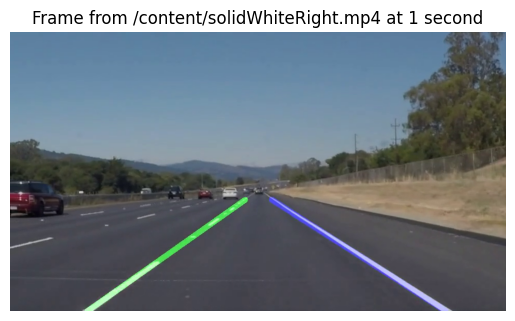

In [ ]:
from moviepy.editor import VideoFileClip
import matplotlib.pyplot as plt

# Define the video path (assuming solidWhiteRight.mp4 is a valid video file)
video_path = '/content/solidWhiteRight.mp4'

# Load the video clip
clip = VideoFileClip(video_path)

# Get a frame at 1 second mark (you can change this to any second)
frame = clip.get_frame(1)

# Display the frame
plt.imshow(frame)
plt.title(f"Frame from {video_path} at 1 second")
plt.axis('off') # Hide axes for cleaner image display
plt.show()

In [ ]:
import os

white_output = '/content_output/solidWhiteRight.mp4'

# Create the output directory if it doesn't exist
output_dir = os.path.dirname(white_output)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
##clip1 = VideoFileClip("test_videos/solidWhiteRight.mp4").subclip(0,5)
clip1 = VideoFileClip("/content/solidWhiteRight.mp4")
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(white_output, audio=False)
previous_lines = [0, 0, 0, 0]

Moviepy - Building video /content_output/solidWhiteRight.mp4.
Moviepy - Writing video /content_output/solidWhiteRight.mp4



Moviepy - Done !
Moviepy - video ready /content_output/solidWhiteRight.mp4
CPU times: user 8.53 s, sys: 450 ms, total: 8.98 s
Wall time: 17.5 s


In [ ]:
white_output = '/content_output/solidWhiteRight.mp4'
## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
##clip1 = VideoFileClip("test_videos/solidWhiteRight.mp4").subclip(0,5)
clip1 = VideoFileClip("/content/solidWhiteRight.mp4")
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(white_output, audio=False)
previous_lines = [0, 0, 0, 0]

Moviepy - Building video /content_output/solidWhiteRight.mp4.
Moviepy - Writing video /content_output/solidWhiteRight.mp4



Moviepy - Done !
Moviepy - video ready /content_output/solidWhiteRight.mp4
CPU times: user 8.59 s, sys: 440 ms, total: 9.03 s
Wall time: 16.3 s


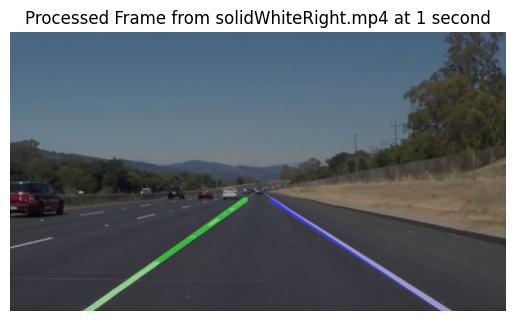

In [ ]:
import matplotlib.pyplot as plt

# Get a frame from the video clip at 1 second mark (or any other time)
frame_to_test = clip.get_frame(1)

# Process the frame using the lane finding pipeline
processed_frame = process_image(frame_to_test)

# Display the processed frame
plt.imshow(processed_frame)
plt.title("Processed Frame from solidWhiteRight.mp4 at 1 second")
plt.axis('off')
plt.show()

In [ ]:
!ffmpeg -i solidWhiteRight.mp4 -vcodec libx264 white_fixed.mp4


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import Video
Video("white_fixed.mp4", embed=True)

In [ ]:
yellow_output = '/content/solidYellowLeft.mp4'
## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
##clip2 = VideoFileClip('test_videos/solidYellowLeft.mp4').subclip(0,5)
clip2 = VideoFileClip('/content/solidYellowLeft.mp4')
yellow_clip = clip2.fl_image(process_image)
%time yellow_clip.write_videofile(yellow_output, audio=False)
previous_lines = [0, 0, 0, 0]

Moviepy - Building video /content/solidYellowLeft.mp4.
Moviepy - Writing video /content/solidYellowLeft.mp4



t:   7%|▋         | 46/681 [00:02<00:39, 15.98it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/solidYellowLeft.mp4, 1555200 bytes wanted but 0 bytes read,at frame 46/682, at time 1.84/27.24 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

t:   7%|▋         | 48/681 [00:02<00:44, 14.16it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/solidYellowLeft.mp4, 1555200 bytes wanted but 0 bytes read,at frame 47/682, at time 1.88/27.24 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

t:   7%|▋         | 50/681 [00:02<00:50, 12.39it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:1

Moviepy - Done !
Moviepy - video ready /content/solidYellowLeft.mp4
CPU times: user 26.5 s, sys: 3.16 s, total: 29.7 s
Wall time: 37.9 s


In [ ]:
import os

video_file_path = '/content/solidYellowLeft.mp4'

if os.path.exists(video_file_path):
    print(f"The file '{video_file_path}' exists.")
    try:
        file_size = os.path.getsize(video_file_path)
        print(f"File size: {file_size} bytes")
        if file_size > 0:
            print("The file is accessible and has content.")
        else:
            print("The file is accessible but is empty.")
    except OSError as e:
        print(f"Error accessing file size: {e}. The file might not be fully accessible.")
else:
    print(f"The file '{video_file_path}' does not exist.")

The file '/content/solidYellowLeft.mp4' exists.
File size: 422236 bytes
The file is accessible and has content.


In [ ]:
!ffmpeg -i solidYellowLeft.mp4 -vcodec libx264 yellow_fixed.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
Video("yellow_fixed.mp4", embed=True)

In [ ]:
!ffprobe /content/challenge.mp4

ffprobe version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2007-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --ena

In [ ]:
challenge_output = '/content/challenge.mp4'
## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
##clip3 = VideoFileClip('test_videos/challenge.mp4').subclip(0,5)
clip3 = VideoFileClip('/content/challenge.mp4')
challenge_clip = clip3.fl_image(process_image)
%time challenge_clip.write_videofile(challenge_output, audio=False)

Moviepy - Building video /content/challenge.mp4.
Moviepy - Writing video /content/challenge.mp4



t:  18%|█▊        | 44/251 [00:02<00:11, 17.82it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/challenge.mp4, 2764800 bytes wanted but 0 bytes read,at frame 44/251, at time 1.76/10.04 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

t:  18%|█▊        | 46/251 [00:02<00:13, 15.53it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/challenge.mp4, 2764800 bytes wanted but 0 bytes read,at frame 45/251, at time 1.80/10.04 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

t:  19%|█▉        | 48/251 [00:02<00:14, 13.83it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarn

Moviepy - Done !
Moviepy - video ready /content/challenge.mp4
CPU times: user 16.4 s, sys: 771 ms, total: 17.1 s
Wall time: 24.2 s


In [ ]:
import os

input_video = '/content/challenge.mp4'
output_video = '/content_output/challenge_repaired.mp4'

# Create the output directory if it doesn't exist
output_dir = os.path.dirname(output_video)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Attempting to repair '{input_video}' by re-muxing to '{output_video}'...")
!ffmpeg -i {input_video} -map 0 -c copy {output_video}

print("Repair attempt finished. You can now try to process 'challenge_repaired.mp4' with MoviePy.")


Attempting to repair '/content/challenge.mp4' by re-muxing to '/content_output/challenge_repaired.mp4'...
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-l

In [ ]:
!ffmpeg -i challenge.mp4 -vcodec libx264 challenge_fixed.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
Video("challenge_fixed.mp4", embed=True)

After running the above cell, you should check the integrity of the newly created `challenge_repaired.mp4` file, and then try to process it with MoviePy.

In [ ]:
import os
from moviepy.editor import VideoFileClip

input_repaired_video_path = '/content_output/challenge_repaired.mp4'
output_processed_repaired_video_path = '/content_output/challenge_repaired_processed.mp4'

# Ensure the output directory exists
output_dir = os.path.dirname(output_processed_repaired_video_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Processing repaired video: {input_repaired_video_path}")
clip_repaired = VideoFileClip(input_repaired_video_path)
challenge_repaired_clip = clip_repaired.fl_image(process_image)

%time challenge_repaired_clip.write_videofile(output_processed_repaired_video_path, audio=False)
previous_lines = [0, 0, 0, 0] # Reset previous_lines for new video processing
print(f"Processed video saved to: {output_processed_repaired_video_path}")


Processing repaired video: /content_output/challenge_repaired.mp4
Moviepy - Building video /content_output/challenge_repaired_processed.mp4.
Moviepy - Writing video /content_output/challenge_repaired_processed.mp4



Moviepy - Done !
Moviepy - video ready /content_output/challenge_repaired_processed.mp4
CPU times: user 16.9 s, sys: 1.33 s, total: 18.2 s
Wall time: 27.9 s
Processed video saved to: /content_output/challenge_repaired_processed.mp4
